# Calculating Dynamic Modulus $G(t)$

For the purposes of classifying/observing the viscoelastic properties of the bulk polymer, we calculate a time averaged dynamic modulus $\bar G(t)$

$$G(t) = \frac V {k_B T} \langle \sigma_{xy}(t)\sigma_{xy}(0)\rangle$$

$$\bar G(t) = \frac 1 t \int_0^t G(t')dt'$$

(Raffaeli and Ellenbroek)

There doesn't seem to be a autocorrelation function for $t=0$, only for small constant time differences, so we can do this in Python post-processing after we have collected pressure data from the LAMMPS simulation.

Pressure from LAMMPS is in LJ units.

As noted in the the `compute stress/atom` docs, "per-atom stress is the negative of the per-atom pressure tensor." So, we can simply use the negative $xy$ component of pressure as the $xy$ component of the stress tensor.

However, this then means that 

$$G(t) = \frac V {k_B T} \langle (-p_{xy}(t))(-p_{xy}(0))\rangle$$
$$G(t) = \frac V {k_B T} \langle p_{xy}(t)p_{xy}(0)\rangle$$

so we can simply replace the stress terms with pressure terms.


      timestep       pxy
1975     19750 -0.003846
1976     19760  0.005644
1977     19770  0.001324
1978     19780  0.000287
1979     19790 -0.004579


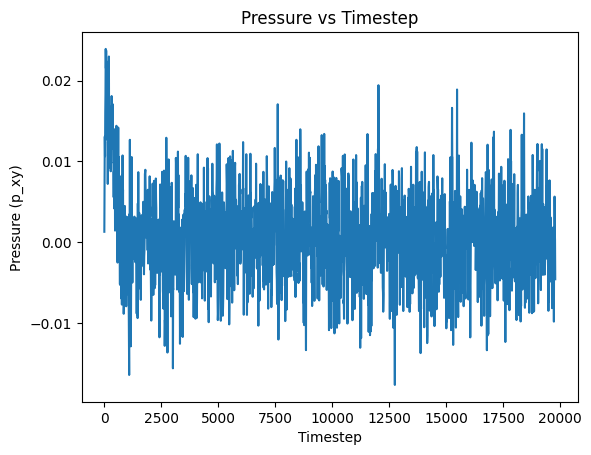

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file = "logs/press_original_test.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'pxy'])
print(data.tail())

plt.plot(data['timestep'], data['pxy'])
plt.xlabel('Timestep')
plt.ylabel('Pressure (p_xy)')
plt.title('Pressure vs Timestep')
plt.show()

(3959,)
(1980,)


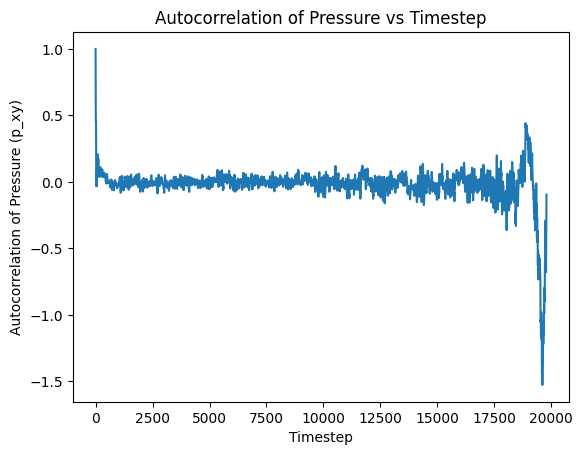

In [2]:
from scipy.signal import correlate
import numpy as np

# calculate time correlation of pxy
pxy = data['pxy']
t = data['timestep']

auto_corr = correlate(pxy - np.mean(pxy), pxy - np.mean(pxy), mode='full')
print(auto_corr.shape)

corr = auto_corr[auto_corr.size // 2:] / np.arange(len(pxy), 0, -1)
print(corr.shape)
corr /= corr[0]  # normalize? not sure if needed

plt.plot(t, corr)
plt.xlabel('Timestep')
plt.ylabel('Autocorrelation of Pressure (p_xy)')
plt.title('Autocorrelation of Pressure vs Timestep')
plt.show()

In [3]:
# time average of autocorrelation

kB = 1.0       # Boltzmann constant = 1 in LJ units
T = 1.0        # temperature
V = 40**3      # volume

G_t = (V / (kB * T)) * corr

time = t
dt = time[1] - time[0]

overline_G = np.cumsum(G_t) * dt / time
overline_G[0] = overline_G[1]  # avoid division by zero
overline_G /= overline_G[0]  # normalize by G(0)

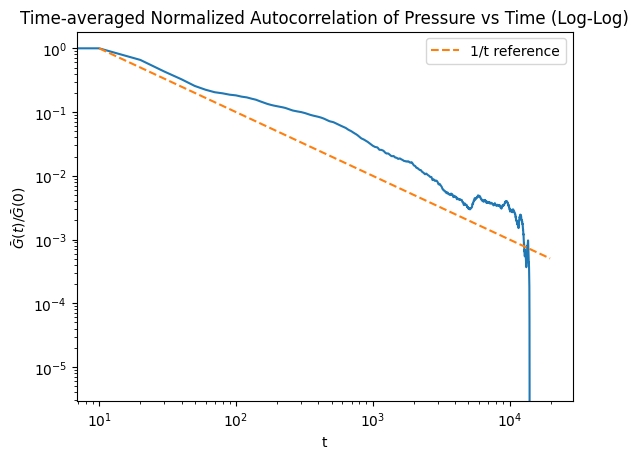

In [4]:
# log log plot
plt.loglog(time, overline_G)
# add 1/t line for reference
plt.loglog(time, 1/time * overline_G[1] * time[1], '--', label='1/t reference')
plt.legend()
plt.xlabel('t')
plt.ylabel(r'$\bar G(t)/\bar G(0)$')
plt.title('Time-averaged Normalized Autocorrelation of Pressure vs Time (Log-Log)')
plt.show()

## $\bar G(t)$ function definition

In [ ]:
from numpy import correlate

def overline_G_func(pxy, t, window_size=1):
    kB = 1.0       # Boltzmann constant = 1 in LJ units
    T = 1.0        # temperature
    V = 40**3      # volume
    # TODO: use constants, currently just using autocorrelation

    auto_corr = correlate(pxy - np.mean(pxy), pxy - np.mean(pxy), mode='full')
    corr = auto_corr[auto_corr.size // 2:] / np.arange(len(pxy), 0, -1)

    # corr /= corr[0]  # normalize? not sure if needed

    time = t
    dt = time[1] - time[0]

    overline_G = np.cumsum(corr) * dt / time
    overline_G[0] = overline_G[1]  # avoid division by zero
    overline_G /= overline_G[0]  # normalize by G(0)
    

    # kernel = np.ones(window_size) / window_size
    # smoothed = np.convolve(overline_G, kernel, mode='valid')
    # pad = (len(overline_G) - len(smoothed)) // 2
    # smoothed = np.pad(smoothed, (pad, len(overline_G) - len(smoothed) - pad), mode='edge')

    return overline_G, time


This looks like it works, so I'll vary some parameters and compare. I did have to scale the $1/t$ line to work with the graph.

# Varying $x_0$ and $A$

Using some optimal values of $x_0$ and $A$, we can look at the $G(t)$ behaviour



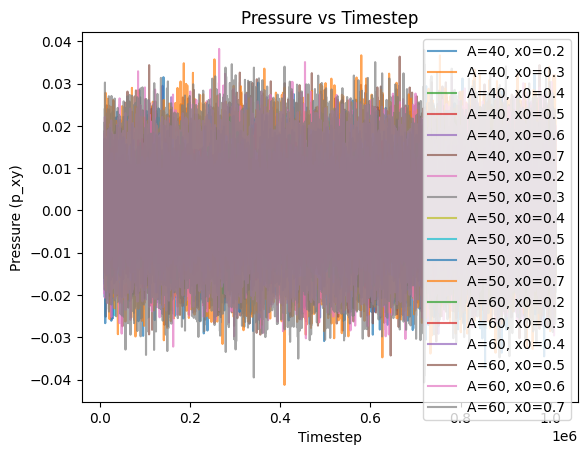

In [12]:
energies= [40, 50, 60]
lengths = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for energy in energies:
    for length in lengths:
        file = f"logs/press_{energy}_{length}.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'pxy'])
        # data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'pxy'])
        # print(data.head())

        plt.plot(data['timestep'], data['pxy'], label=f'A={energy}, x0={length}', alpha=0.7)
        plt.xlabel('Timestep')
        plt.ylabel('Pressure (p_xy)')
        plt.title('Pressure vs Timestep')
        plt.legend()
plt.show()

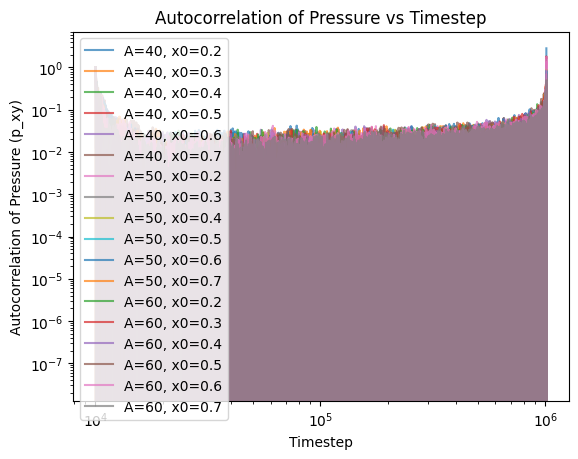

In [13]:
# calculate time correlation of pxy for different parameters

energies= [40, 50, 60]
lengths = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for energy in energies:
    for length in lengths:
        file = f"logs/press_{energy}_{length}.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'pxy'])
        # calculate time correlation of pxy
        pxy = data['pxy']
        t = data['timestep']

        auto_corr = correlate(pxy - np.mean(pxy), pxy - np.mean(pxy), mode='full')
        corr = auto_corr[auto_corr.size // 2:] / np.arange(len(pxy), 0, -1)

        corr /= corr[0]  # normalize? not sure if needed

        plt.loglog(t, corr, label=f'A={energy}, x0={length}', alpha=0.7)
        plt.xlabel('Timestep')
        plt.ylabel('Autocorrelation of Pressure (p_xy)')
        plt.title('Autocorrelation of Pressure vs Timestep')
        plt.legend()
plt.show()

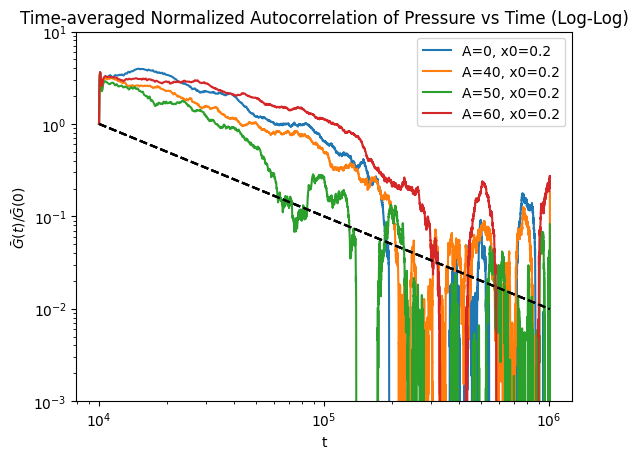

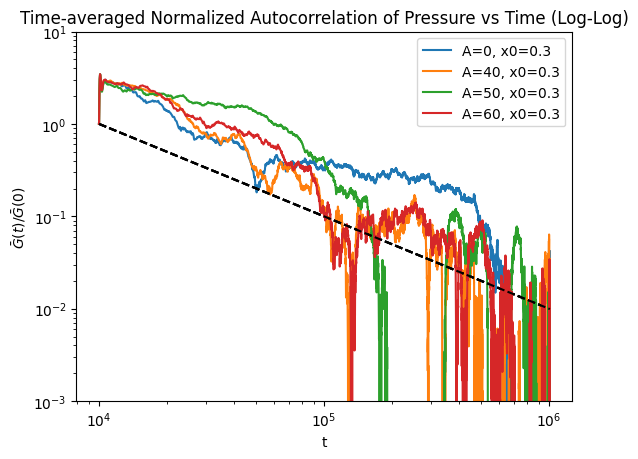

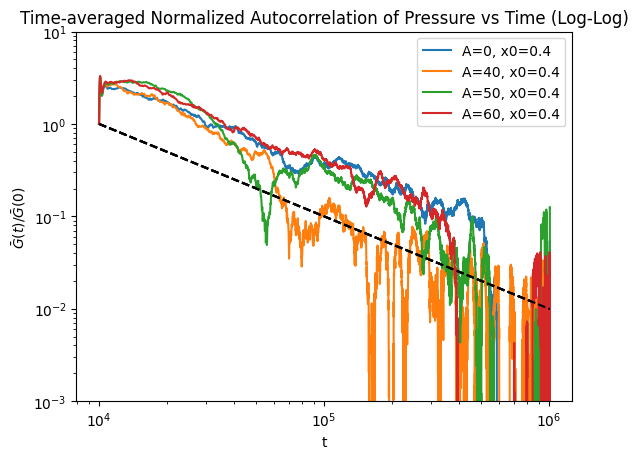

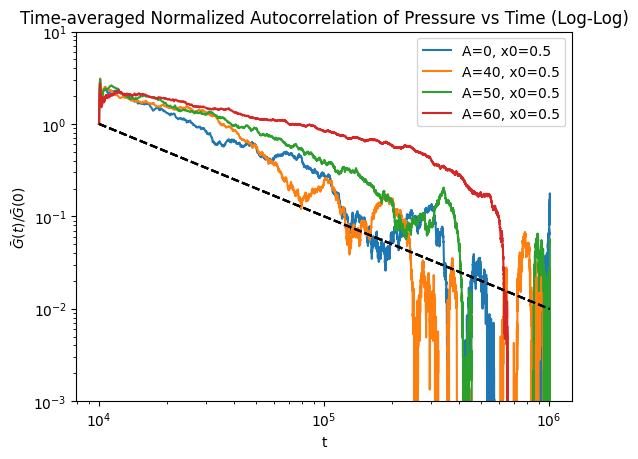

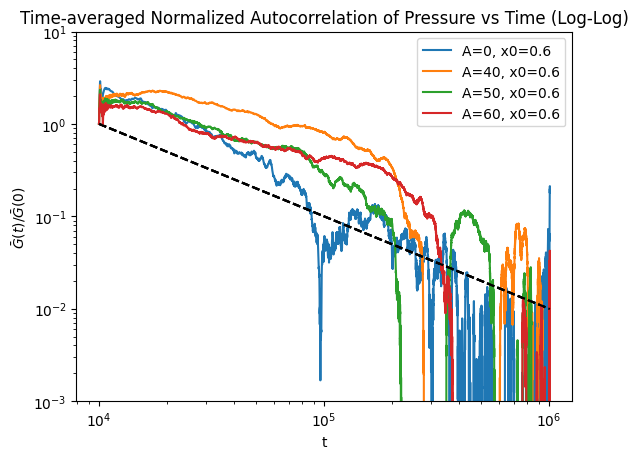

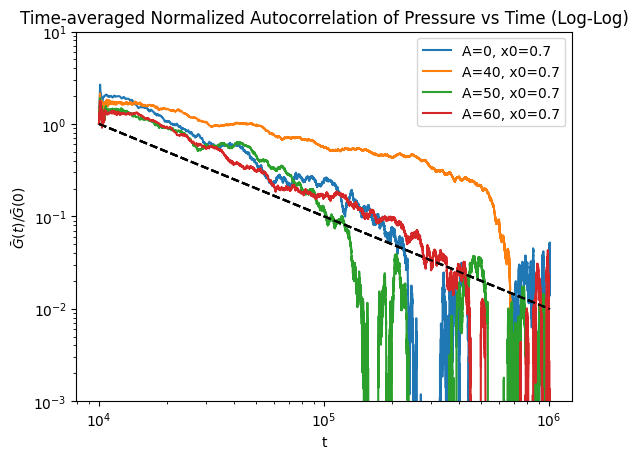

In [14]:
# time average of autocorrelation for different parameters

energies= [0, 40, 50, 60]
lengths = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
    
for length in lengths:
    for energy in energies:
        file = f"logs/press_{energy}_{length}.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'pxy'])
        # calculate time correlation of pxy
        pxy = data['pxy']
        t = data['timestep']
    
        overline_G, time = overline_G_func(pxy, t, window_size=200)

        # log log plot
        plt.loglog(time, overline_G, label=f'A={energy}, x0={length}')
        # add 1/t line for reference
        plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')
        plt.legend()
        plt.xlabel('t')
        plt.ylabel(r'$\bar G(t)/\bar G(0)$')
        plt.ylim(1e-3, 10)
        plt.title('Time-averaged Normalized Autocorrelation of Pressure vs Time (Log-Log)')
        plt.legend()
    plt.show()

# Chains without Dummy Beads

The previous sections were done with a chain setup where the patches would be attached to dummy beads, which would then be attached to the backbone. The dummy and backbone beads are identical, but the structure is changed as the patches would then "stick out" from the backbone with the dummy.

I also tried changing the structure so that there are no dummies and the patches are attached directly to the backbone. This should conceivably increase the steric repulsion of the backbone for the patch-patch bonds, as there are more WCA-repulsive beads closer to the bonding location. This isn't guaranteeed -- the interaction range of the beads (~1.5) mean that it is possible for the beads to be away from the patch-patch site. On average, there is more repulsion.

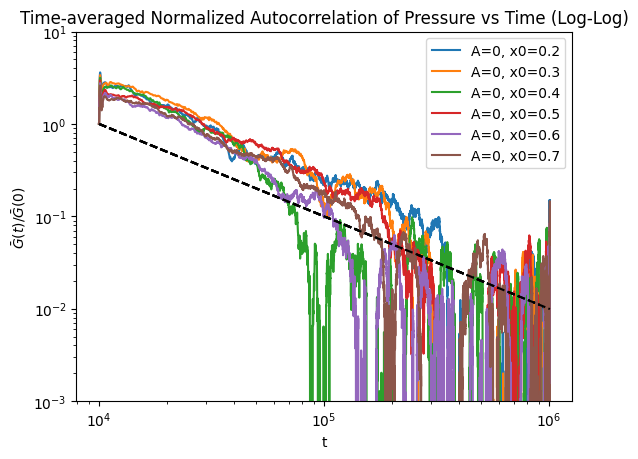

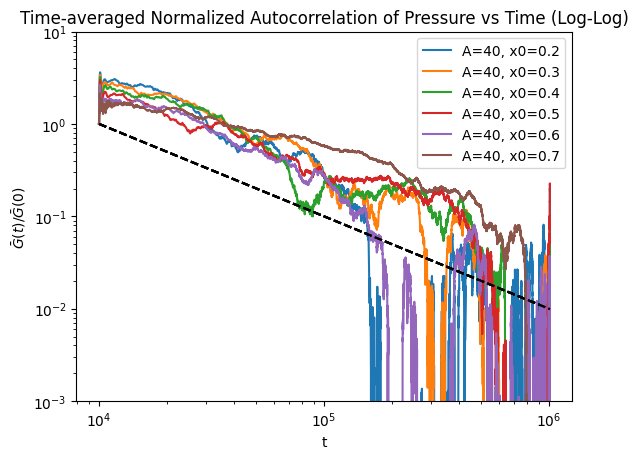

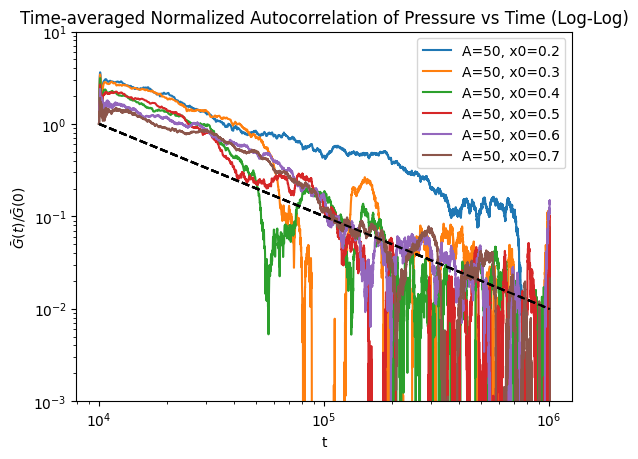

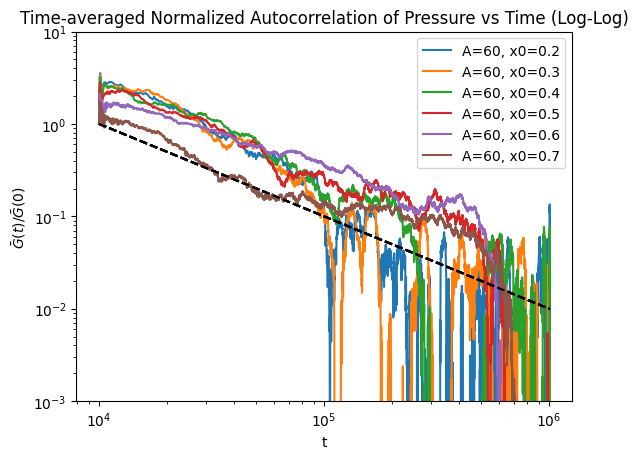

In [9]:
# time average of autocorrelation for different parameters

energies= [0, 40, 50, 60]
lengths = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for energy in energies:
    for length in lengths:
        file = f"logs/no_dummy_press_{energy}_{length}.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'pxy'])
        # calculate time correlation of pxy
        pxy = data['pxy']
        t = data['timestep']
    
        overline_G, time = overline_G_func(pxy, t, window_size=200)

        # log log plot
        plt.loglog(time, overline_G, label=f'A={energy}, x0={length}')
        # add 1/t line for reference
        plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')
        plt.legend()
        plt.xlabel('t')
        plt.ylabel(r'$\bar G(t)/\bar G(0)$')
        plt.ylim(1e-3, 10)
        plt.title('Time-averaged Normalized Autocorrelation of Pressure vs Time (Log-Log)')
        plt.legend()
    plt.show()

There is some variation to the relaxation behaviour.

## Varying number of patches 

Changing number of patches is similar to the reference paper. Varying $n$ is the number of backbone beads per patch -- $n=1$ means every backbone has a patch, $n=2$ means every second backbone, etc. The dummies are still not being used so that the total number of WCA beads does not change.

80001


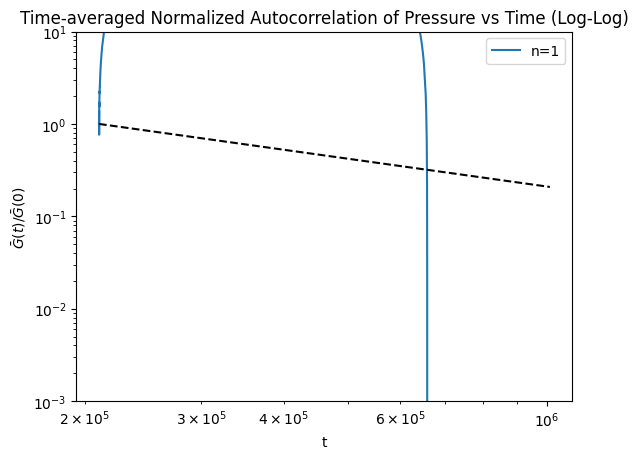

80001


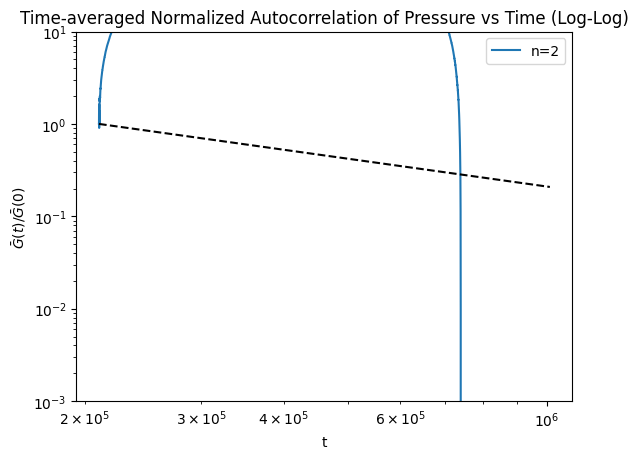

5290


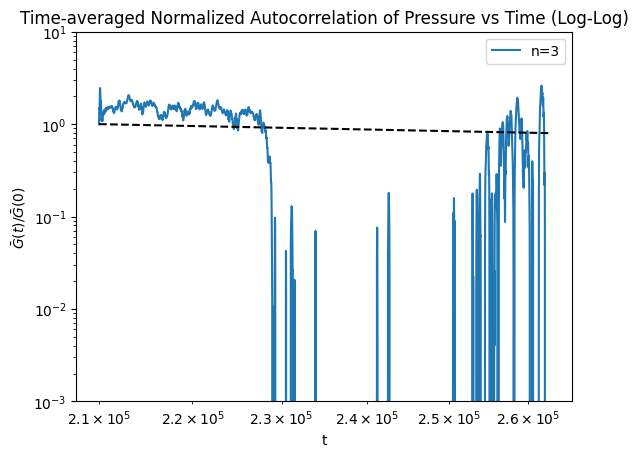

80001


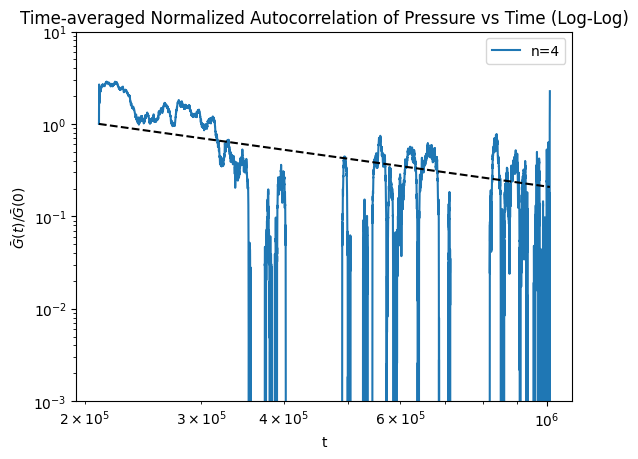

In [36]:
# time average of autocorrelation for different parameters (varying n patches)

n = [1, 2, 3, 4]

for n_patches in n:
    file = f"logs/patch_n_{n_patches}_50_0.5.dat"
    data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'pxy'])
    # calculate time correlation of pxy
    pxy = data['pxy'][20000:].to_numpy()  # skip initial transient
    t = data['timestep'][20000:].to_numpy()  # skip initial transient
    print(len(pxy))


    overline_G, time = overline_G_func(pxy, t, window_size=200)

    # log log plot
    plt.loglog(time, overline_G, label=f'n={n_patches}')
    # add 1/t line for reference
    plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')
    plt.legend()
    plt.xlabel('t')
    plt.ylabel(r'$\bar G(t)/\bar G(0)$')
    plt.ylim(1e-3, 10)
    plt.title('Time-averaged Normalized Autocorrelation of Pressure vs Time (Log-Log)')
    plt.legend()
    plt.show()

There is definitely a variation here

NOTE: there's something wrong with the autocorrelation calculations that I'm trying to figure out. They should not pop above 1 at the beginning, the correlation should not be above 1.

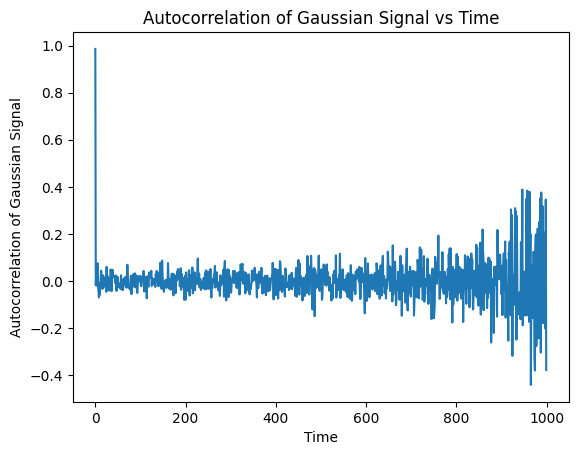

In [ ]:
dist = np.random.normal(size=1000)

auto_corr = correlate(dist - np.mean(dist), dist - np.mean(dist), mode='full')
corr = auto_corr[auto_corr.size // 2:] / np.arange(len(dist), 0, -1)

plt.plot(corr)
plt.xlabel('Time')
plt.ylabel('Autocorrelation of Gaussian Signal')
plt.title('Autocorrelation of Gaussian Signal vs Time')
plt.show()

/tmp/ipykernel_367021/2871028673.py:20: RuntimeWarning: divide by zero encountered in divide
  overline_G = np.cumsum(corr) * dt / time
/tmp/ipykernel_367021/132894327.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')


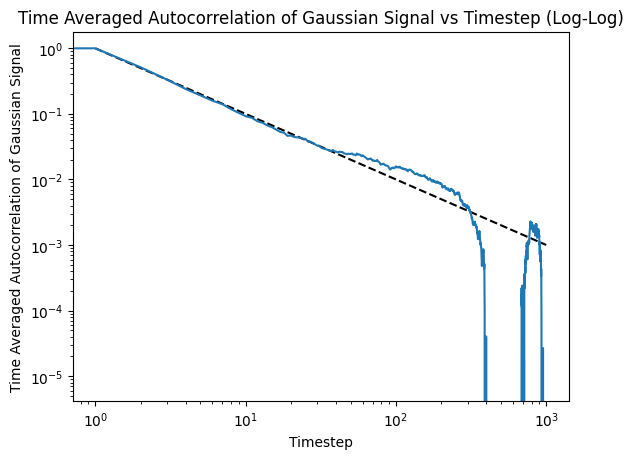

In [43]:
overline_G, time = overline_G_func(dist, np.arange(len(dist)), window_size=10)

plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')
plt.loglog(time, overline_G)
plt.xlabel('Timestep')
plt.ylabel('Time Averaged Autocorrelation of Gaussian Signal')
plt.title('Time Averaged Autocorrelation of Gaussian Signal vs Timestep (Log-Log)')
plt.show()